In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def copy_move_tespiti_coklu(image_path, algoritma="SIFT"):
    img = cv2.imread(image_path)
    if img is None:
        print("Görüntü bulunamadı.")
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Algoritma Seçimi ve Mesafe Ölçüm Tipi Belirleme
    if algoritma == "SIFT":
        detector = cv2.SIFT_create()
        norm_type = cv2.NORM_L2
    elif algoritma == "SURF":
        try:
            detector = cv2.xfeatures2d.SURF_create()
        except AttributeError:
            print("Hata: SURF bu OpenCV sürümünde aktif değil. opencv-contrib-python kurun.")
            return
        norm_type = cv2.NORM_L2
    elif algoritma == "AKAZE":
        detector = cv2.AKAZE_create()
        norm_type = cv2.NORM_HAMMING
    elif algoritma == "ORB":
        detector = cv2.ORB_create()
        norm_type = cv2.NORM_HAMMING
    else:
        print("Geçersiz algoritma! Lütfen SIFT, SURF, AKAZE veya ORB girin.")
        return

    # 2. Anahtar Noktaları Çıkar
    keypoints, descriptors = detector.detectAndCompute(gray, None)
    
    if descriptors is None:
        print(f"{algoritma} görüntüde yeterli anahtar nokta bulamadı.")
        return

    # 3. Eşleştiriciyi Hazırla (Algoritmaya özel norm_type kullanılıyor)
    bf = cv2.BFMatcher(norm_type)
    matches = bf.knnMatch(descriptors, descriptors, k=3)

    good_matches = []
    min_mesafe = 50

    # 4. Anlamlı Eşleşmeleri Filtrele (Lowe's Ratio Test)
    for match in matches:
        if len(match) == 3:
            m1, m2, m3 = match
            
            # Ratio testi (0.75 - 0.80 genelde optimumdur)
            if m2.distance < 0.75 * m3.distance:
                pt1 = np.array(keypoints[m1.queryIdx].pt)
                pt2 = np.array(keypoints[m2.trainIdx].pt)
                
                mesafe = np.linalg.norm(pt1 - pt2)
                
                if mesafe > min_mesafe:
                    good_matches.append(cv2.DMatch(m1.queryIdx, m2.trainIdx, m2.distance))

    # 5. Eşleşmeleri Görüntü Üzerine Çiz
    result_img = cv2.drawMatches(img_rgb, keypoints, img_rgb, keypoints, good_matches, None, 
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS, 
                                 matchColor=(255, 0, 0))

    # 6. Ekrana Bas
    plt.figure(figsize=(15, 10))
    plt.imshow(result_img)
    plt.title(f"{algoritma} ile Tespit Edilen Bağlantılar: {len(good_matches)}")
    plt.axis("off")
    plt.show()

    return len(good_matches)

Okunacak tam yol: /app/data/An-example-of-copy-move-forgery-from-CASIA-database.png
--- SIFT Testi Başlıyor ---


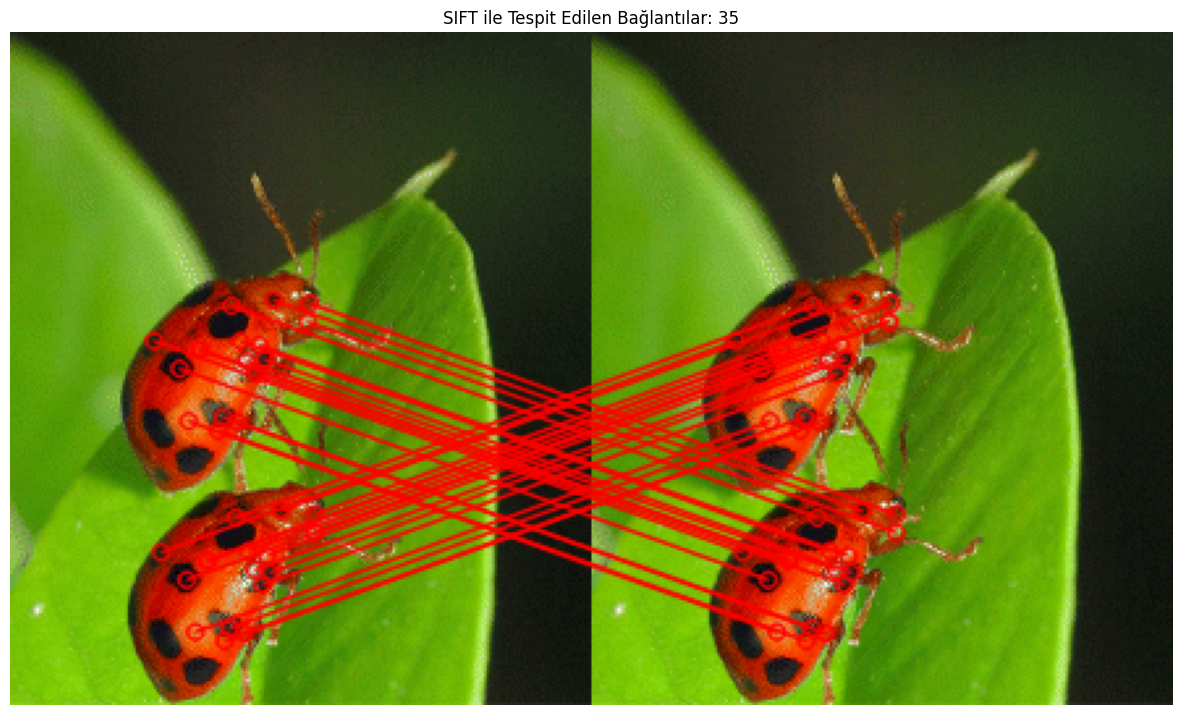

--- AKAZE Testi Başlıyor ---


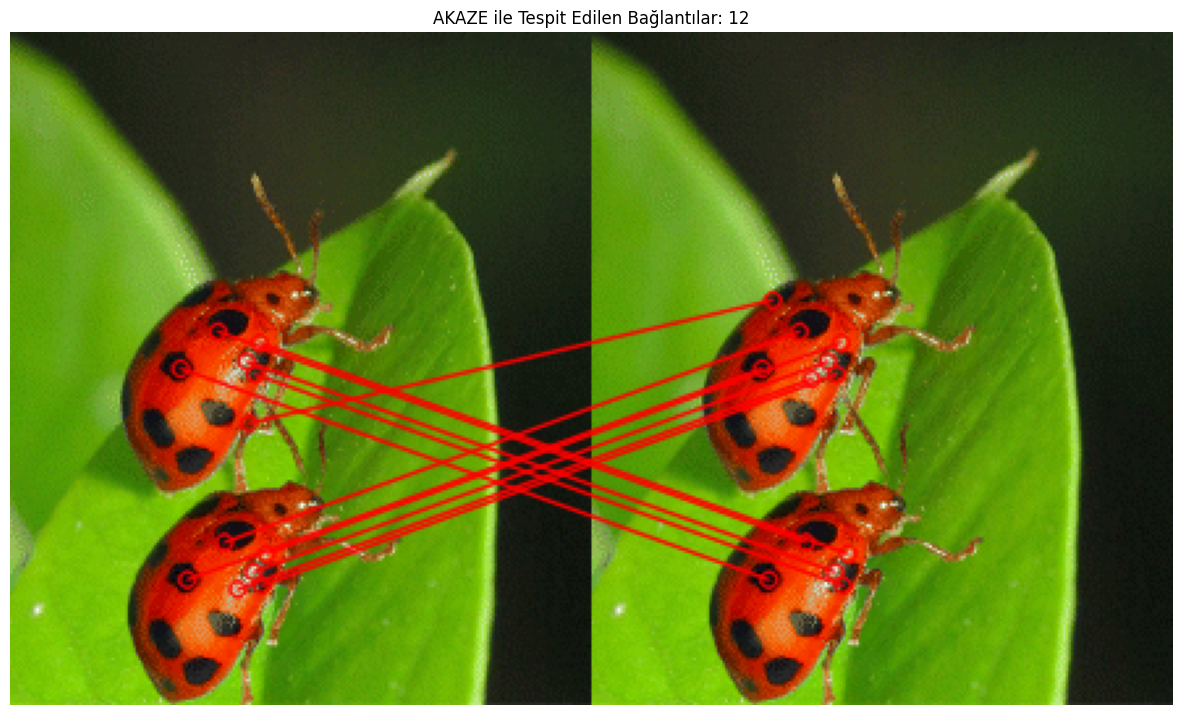

--- ORB Testi Başlıyor ---


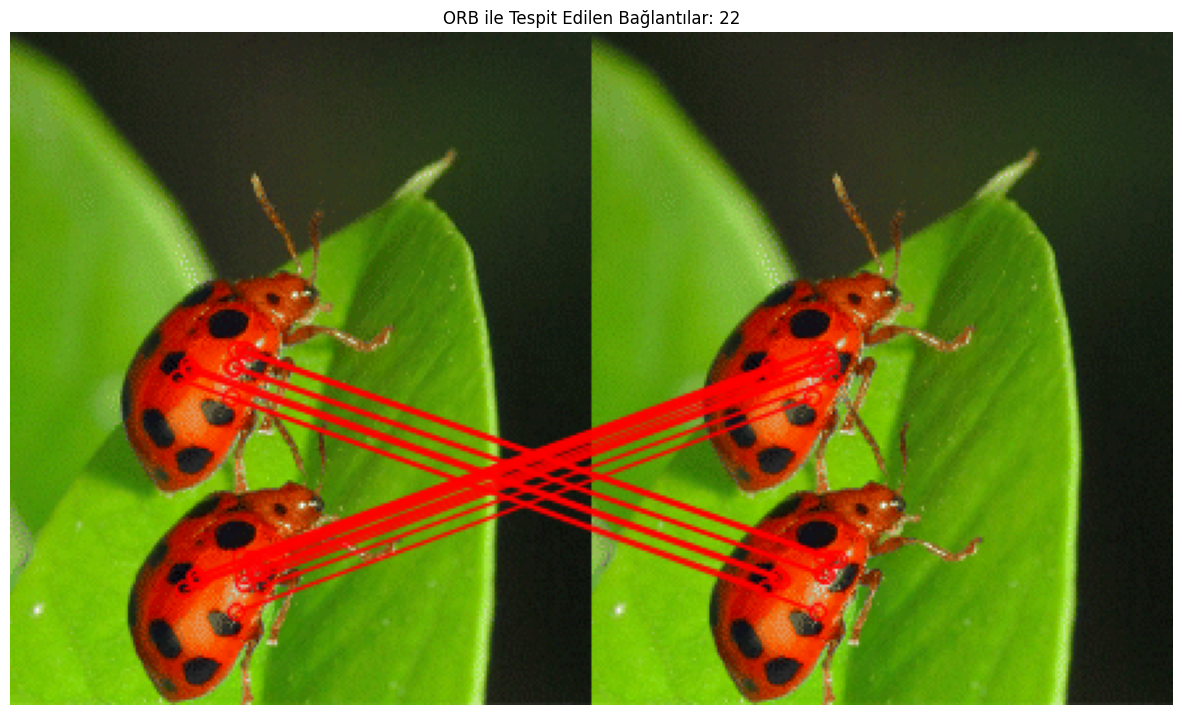

--- SURF Testi Başlıyor ---


error: OpenCV(4.8.0) /io/opencv_contrib/modules/xfeatures2d/src/surf.cpp:1026: error: (-213:The function/feature is not implemented) This algorithm is patented and is excluded in this configuration; Set OPENCV_ENABLE_NONFREE CMake option and rebuild the library in function 'create'


In [9]:
from pathlib import Path

# 1. Notebook 'src' içinde çalıştığı için cwd() bize '/app/src' dizinini verir.
# 2. .parent ile bir üst dizine ('/app') çıkarız.
# 3. Ardından 'data' klasörüne ve dosyamıza ulaşırız.
BASE_DIR = Path.cwd().parent
resim_yolu = BASE_DIR / "data" / "An-example-of-copy-move-forgery-from-CASIA-database.png"

print(f"Okunacak tam yol: {resim_yolu}")

# Test döngüsü
algoritmalar = ["SIFT", "AKAZE", "ORB", "SURF"]

for algo in algoritmalar:
    print(f"--- {algo} Testi Başlıyor ---")
    # path objesini stringe çevirerek fonksiyona yolluyoruz
    copy_move_tespiti_coklu(str(resim_yolu), algoritma=algo)